Problem statement: To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

### Importing Skin Cancer Data
#### To do: Take necessary actions to read the data

### Importing all the important libraries

In [175]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
## If you are using the data by mounting the google drive, use the following :
## from google.colab import drive
## drive.mount('/content/gdrive')

##Ref:https://towardsdatascience.com/downloading-datasets-into-google-drive-via-google-colab-bcb1b30b0166

This assignment uses a dataset of about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [177]:
# Defining the path for train and test images
## Todo: Update the paths of the train and test dataset
data_dir_train = pathlib.Path(r"F:\CNN_Assignment\Skin cancer ISIC The International Skin Imaging Collaboration\Train")
data_dir_test = pathlib.Path(r"F:\CNN_Assignment\Skin cancer ISIC The International Skin Imaging Collaboration\Test")


In [179]:
# Count images in the train directory
image_count_train = len(list(data_dir_train.glob('**/*.jpg')))
print(f"Total train images: {image_count_train}")

# Count images in the test directory
image_count_test = len(list(data_dir_test.glob('**/*.jpg')))
print(f"Total test images: {image_count_test}")

Total train images: 2239
Total test images: 118


### Load using keras.preprocessing

Let's load these images off disk using the helpful image_dataset_from_directory utility.

### Create a dataset

Define some parameters for the loader:

In [181]:
batch_size = 32
img_height = 180
img_width = 180

Use 80% of the images for training, and 20% for validation.

In [183]:
## Write your train dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split = 0.2,
    subset='training',
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


In [80]:
## Write your validation dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split = 0.2,
    subset='validation',
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 447 files for validation.


In [185]:
# List out all the classes of skin cancer and store them in a list. 
# You can find the class names in the class_names attribute on these datasets. 
# These correspond to the directory names in alphabetical order.
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


### Visualize the data
#### Todo, create a code to visualize one instance of all the nine classes present in the dataset

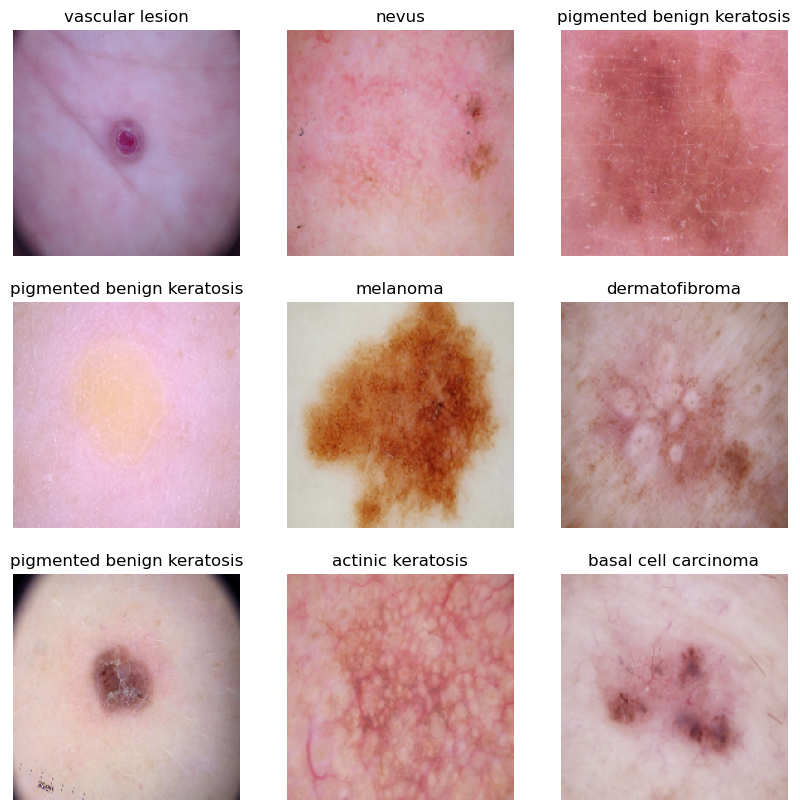

In [187]:
import matplotlib.pyplot as plt

### your code goes here, you can use training or validation data to visualize


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

The `image_batch` is a tensor of the shape `(32, 180, 180, 3)`. This is a batch of 32 images of shape `180x180x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(32,)`, these are corresponding labels to the 32 images.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [189]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Create the model
#### Todo: Create a CNN model, which can accurately detect 9 classes present in the dataset. Use ```layers.experimental.preprocessing.Rescaling``` to normalize pixel values between (0,1). The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network. Here, it is good to standardize values to be in the `[0, 1]`

In [191]:
### Your code goes here

# Number of target labels
target_labels = 9

# Define the model
model = Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),  # Corrected Rescaling
    layers.Conv2D(16, (3, 3), padding='same', activation=tf.nn.relu),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), padding='same', activation=tf.nn.relu),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), padding='same', activation=tf.nn.relu),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation=tf.nn.relu),
    layers.Dense(target_labels, activation='softmax')  # For classification with probabilities
])



### Compile the model
Choose an appropirate optimiser and loss function for model training 

In [193]:
### Todo, choose an appropirate optimiser and loss function
### Todo, choose an appropirate optimiser and loss function
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [197]:
# View the summary of all layers
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,801 (15.22 MB)

 Trainable params: 3,989,801 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [199]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 58s 257ms/step - accuracy: 0.2226 - loss: 2.2401 - val_accuracy: 0.3602 - val_loss: 1.7819
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.3531 - loss: 1.7569 - val_accuracy: 0.4452 - val_loss: 1.6262
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 207ms/step - accuracy: 0.4565 - loss: 1.5198 - val_accuracy: 0.5190 - val_loss: 1.4656
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - accuracy: 0.5179 - loss: 1.3844 - val_accuracy: 0.4855 - val_loss: 1.4853
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 209ms/step - accuracy: 0.5063 - loss: 1.3875 - val_accuracy: 0.5436 - val_loss: 1.3570
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step - accuracy: 0.5585 - loss: 1.2339 - val_accuracy: 0.5391 - val_loss: 1.3977
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step - accuracy: 0.5800 - loss: 1.1744 - val_accuracy: 0.5213 - val_loss: 1.4166
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.6288 - loss: 1.0471 - val_accu

### Visualizing training results

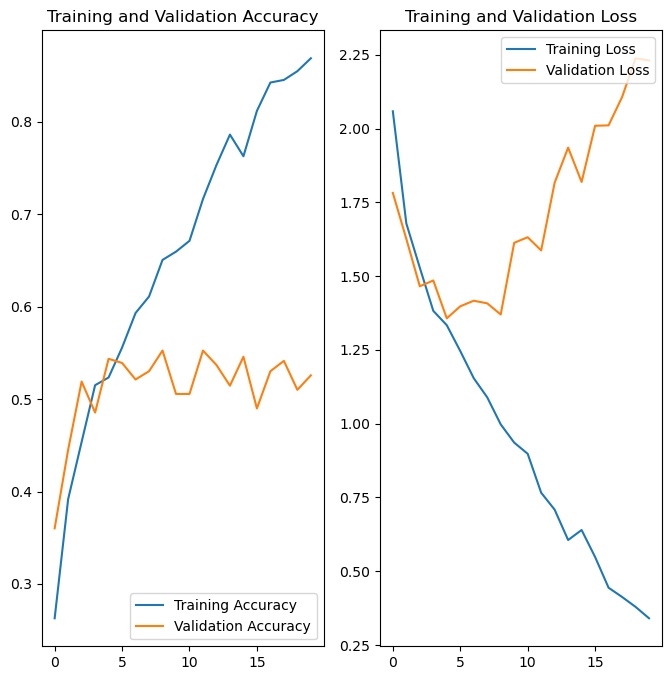

In [201]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit

### Write your findings here



Observations:

    The model's training accuracy shows a steady increase of upto 90%, while validation accuracy remains consistently around 55%.

    A high training accuracy suggests the model has effectively captured the noise within the data. However, its poor performance on validation data indicates a lack of generalizability.

    These observations confirm the presence of overfitting. To address this issue, augmentation techniques will be employed. Given the limited training data available, new samples will be generated by making slight modifications to existing data (such as horizontal/vertical image flipping, minor image rotations, etc.), which will then be used for training the model.



In [374]:
# Todo, after you have analysed the model fit history for presence of underfit or overfit, choose an appropriate data augumentation strategy. 
# Your code goes here

path_to_training_dataset = "F:/CNN_Assignment/Skin cancer ISIC The International Skin Imaging Collaboration/Train/"
import Augmentor

for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)


Initialised with 114 image(s) found.
Output directory set to F:/CNN_Assignment/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis\output.Initialised with 376 image(s) found.
Output directory set to F:/CNN_Assignment/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma\output.Initialised with 95 image(s) found.
Output directory set to F:/CNN_Assignment/Skin cancer ISIC The International Skin Imaging Collaboration/Train/dermatofibroma\output.Initialised with 438 image(s) found.
Output directory set to F:/CNN_Assignment/Skin cancer ISIC The International Skin Imaging Collaboration/Train/melanoma\output.Initialised with 357 image(s) found.
Output directory set to F:/CNN_Assignment/Skin cancer ISIC The International Skin Imaging Collaboration/Train/nevus\output.Initialised with 462 image(s) found.
Output directory set to F:/CNN_Assignment/Skin cancer ISIC The International Skin Imaging Collaboration/Train/pigmented benig

In [376]:
#Count total number of image generated by Augmentor.
image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

4500


In [378]:
# train dataset 
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train, batch_size=32,
                                                               image_size=(180,180), label_mode='categorical',
                                                               seed=123,subset="training",
                                                               validation_split=0.2)

#label_mode is categorial, the labels are a float32 tensor of shape (batch_size, num_classes),
#representing a one-hot encoding of the class index.

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


In [382]:
# validation dataset 
val_ds =tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,batch_size=32,
                                                            image_size=(180,180), label_mode='categorical',
                                                            seed=123,subset="validation",
                                                            validation_split=0.2)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


In [384]:
#tf.data.experimental.AUTOTUNE defines appropriate number of processes that are free for working.

#`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

#`Dataset.prefetch()` overlaps data preprocessing and model execution while training.


AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [386]:
#CNN Model Architecture

#CNN Model Architecture

# Sequential allows you to create models layer-by-layer  
model = Sequential()

# Rescaling Layer
model.add(layers.Rescaling(1./255, input_shape=(180, 180, 3)))

# First Convolution layer
model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Second Convolution Layer
model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Third Convolution Layer
model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Dropout layer with 50% fraction of the input units to drop.
model.add(layers.Dropout(0.5))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(128, activation='relu'))

# Dropout layer with 25% fraction of the input units to drop.
model.add(layers.Dropout(0.25))

# Dense Layer with softmax activation function.
# Softmax scales numbers/logits into probabilities.
model.add(layers.Dense(len(class_names), activation='softmax'))

model.summary()

C:\Users\Nikki\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_38 (MaxPooling2D)      │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 128)                 │       6,553,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,648,137 (25.36 MB)

 Trainable params: 6,648,137 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [388]:
# vizualizing the model from tensorflow.keras.utils import plot_model
# Install necessary dependencies for visualization
!pip install pydot graphviz


Compile the Model

1. Adam optimization: is a stochastic gradient descent method that is based on adaptive estimation of first-order and second-order moments.
categorical_crossentropy: Used as a loss function for multi-class classification model where there are two or more output labels.

In [397]:
model.compile(optimizer="Adam",loss="categorical_crossentropy",metrics=["accuracy"])

#ModelCheckpoint callback is used in conjunction with training using model.fit() to save a model or weights (in a checkpoint file) at some interval,
#so the model or weights can be loaded later to continue the training from the state saved.
checkpoint = ModelCheckpoint("model.h5",monitor="val_accuracy",save_best_only=True,mode="auto",verbose=1)

#Stop training when a monitored metric has stopped improving.
earlystop = EarlyStopping(monitor="val_accuracy",patience=5,mode="auto",verbose=1)

In [399]:
# Train the model
epochs = 20
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,callbacks=[checkpoint,earlystop])

Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.2477 - loss: 1.9985
Epoch 1: val_accuracy improved from -inf to 0.42316, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 122s 509ms/step - accuracy: 0.2482 - loss: 1.9973 - val_accuracy: 0.4232 - val_loss: 1.4582
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.4278 - loss: 1.5054
Epoch 2: val_accuracy improved from 0.42316 to 0.50111, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 83s 488ms/step - accuracy: 0.4278 - loss: 1.5052 - val_accuracy: 0.5011 - val_loss: 1.2746
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.4954 - loss: 1.3311
Epoch 3: val_accuracy improved from 0.50111 to 0.52635, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 81s 478ms/step - accuracy: 0.4954 - loss: 1.3311 - val_accuracy: 0.5264 - val_loss: 1.2319
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.4996 - loss: 1.2576
Epoch 4: val_accuracy improved from 0.52635 to 0.55828, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 79s 470ms/step - accuracy: 0.4998 - loss: 1.2574 - val_accuracy: 0.5583 - val_loss: 1.2228
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.5665 - loss: 1.1396
Epoch 5: val_accuracy improved from 0.55828 to 0.61099, saving model to model.h5


...

169/169 ━━━━━━━━━━━━━━━━━━━━ 80s 475ms/step - accuracy: 0.7883 - loss: 0.5770 - val_accuracy: 0.7840 - val_loss: 0.6640
Epoch 12/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7819 - loss: 0.5791
Epoch 12: val_accuracy did not improve from 0.78396
169/169 ━━━━━━━━━━━━━━━━━━━━ 80s 471ms/step - accuracy: 0.7819 - loss: 0.5791 - val_accuracy: 0.7728 - val_loss: 0.6973
Epoch 13/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.8081 - loss: 0.5100
Epoch 13: val_accuracy did not improve from 0.78396
169/169 ━━━━━━━━━━━━━━━━━━━━ 77s 458ms/step - accuracy: 0.8081 - loss: 0.5101 - val_accuracy: 0.7647 - val_loss: 0.6702
Epoch 14/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8303 - loss: 0.4534
Epoch 14: val_accuracy improved from 0.78396 to 0.80846, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 81s 478ms/step - accuracy: 0.8303 - loss: 0.4535 - val_accuracy: 0.8085 - val_loss: 0.6238
Epoch 15/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8259 - loss: 0.4838
Epoch 15: val_accuracy did not improve from 0.80846
169/169 ━━━━━━━━━━━━━━━━━━━━ 80s 474ms/step - accuracy: 0.8259 - loss: 0.4837 - val_accuracy: 0.7647 - val_loss: 0.8028
Epoch 16/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.8441 - loss: 0.4270
Epoch 16: val_accuracy did not improve from 0.80846
169/169 ━━━━━━━━━━━━━━━━━━━━ 81s 481ms/step - accuracy: 0.8441 - loss: 0.4270 - val_accuracy: 0.8033 - val_loss: 0.6821
Epoch 17/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8470 - loss: 0.4183
Epoch 17: val_accuracy improved from 0.80846 to 0.82702, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 80s 471ms/step - accuracy: 0.8470 - loss: 0.4183 - val_accuracy: 0.8270 - val_loss: 0.5576
Epoch 18/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.8592 - loss: 0.3712
Epoch 18: val_accuracy improved from 0.82702 to 0.83593, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 82s 486ms/step - accuracy: 0.8592 - loss: 0.3713 - val_accuracy: 0.8359 - val_loss: 0.6151
Epoch 19/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8793 - loss: 0.3194
Epoch 19: val_accuracy improved from 0.83593 to 0.84187, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 80s 471ms/step - accuracy: 0.8793 - loss: 0.3195 - val_accuracy: 0.8419 - val_loss: 0.5705
Epoch 20/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8547 - loss: 0.4101
Epoch 20: val_accuracy did not improve from 0.84187
169/169 ━━━━━━━━━━━━━━━━━━━━ 85s 503ms/step - accuracy: 0.8548 - loss: 0.4099 - val_accuracy: 0.8411 - val_loss: 0.5969


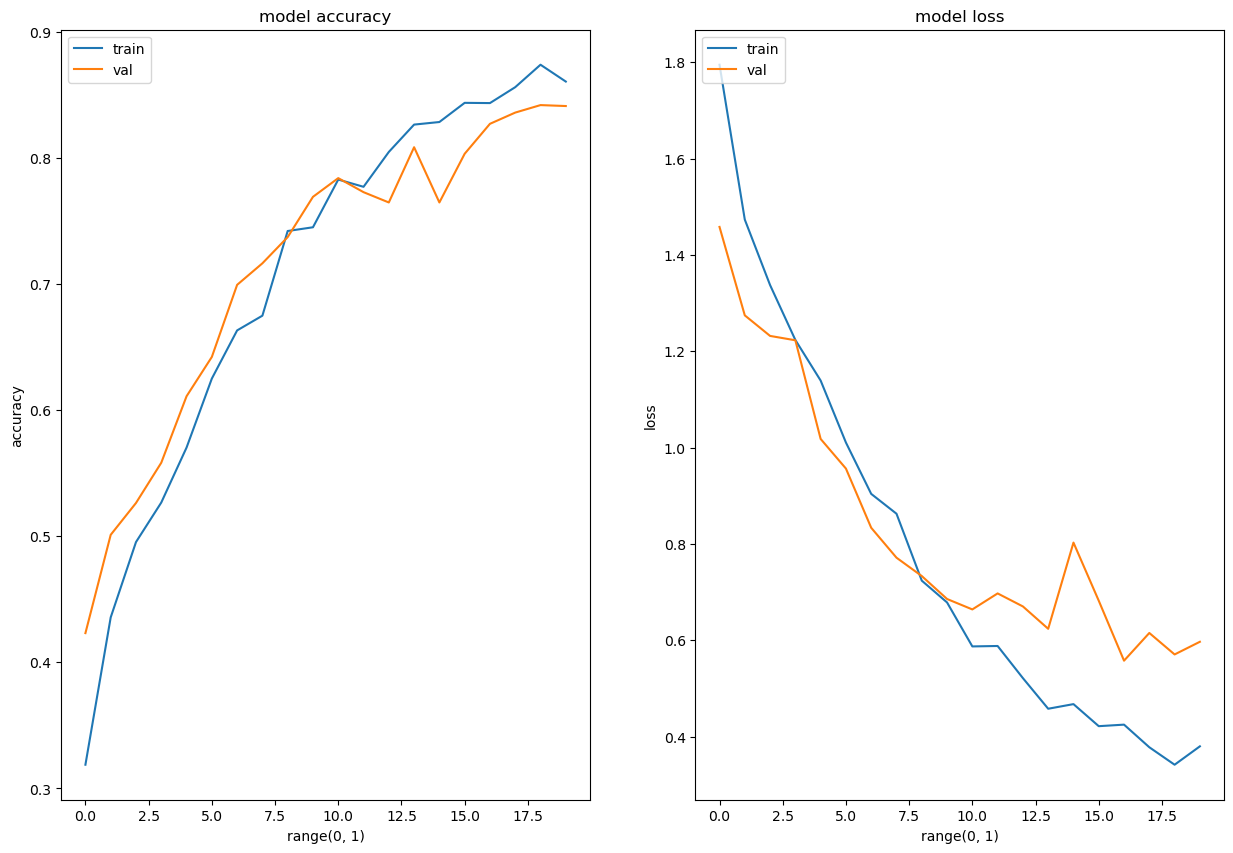

In [401]:
# Plot the training curves

epochs_range = range(earlystop.stopped_epoch+1)

plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)

#Plot Model Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel(epochs_range)
plt.legend(['train', 'val'], loc='upper left')

#Plot Model Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel(epochs_range)
plt.legend(['train', 'val'], loc='upper left')
plt.show()


## Model Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
Actual Class basal cell carcinoma
Predictive Class squamous cell carcinoma


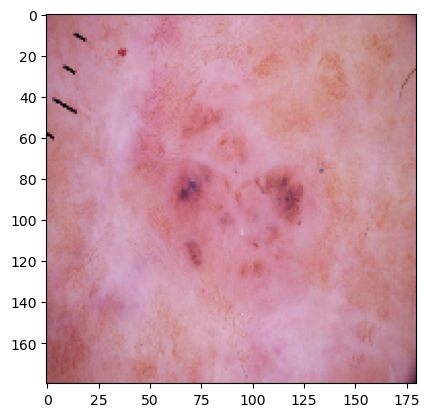

In [406]:
from glob import glob
Test_image_path = os.path.join(data_dir_test, class_names[1], '*')
Test_image = glob(Test_image_path)
Test_image = load_img(Test_image[-1],target_size=(180,180,3))
plt.imshow(Test_image)
plt.grid(False)

img = np.expand_dims(Test_image,axis=0)
pred = model.predict(img)
pred = np.argmax(pred)
pred_class = class_names[pred]
print("Actual Class "+ class_names[1] +'\n'+ "Predictive Class "+pred_class )

#### **Todo:** Write your findings here: 
#### - Which class has the least number of samples?
#### - Which classes dominate the data in terms proportionate number of samples?


Observations:
###
Model Performance
   
Train-Test Accuracy Difference: The model shows an accuracy of ~86% on the training data and ~84% on the test data. The small gap between train and test accuracy indicates that the model generalizes well to unseen data and is not overfitting.

Loss Values:

The training loss is 0.4, while the test loss is higher at 0.7. This suggests that the model has slightly higher error on the test set. While this is not ideal, the difference is within acceptable bounds, considering the task complexity.

High Accuracy: An accuracy of 84% on the test data is promising, especially for a medical imaging task like melanoma detection. However, the implications of false negatives in such a critical domain should be thoroughly analyzed.ively.


